[INFO] Memuat Dataset Benchmark STEAD 10k (1C): STEAD_10k_1C_20260726_173059.json


2026-07-26 18:54:25,477 - [INFO]: Memuat model deep learning MCU-Quake 1D...


[INFO] Total trace yang dimuat: 10000


2026-07-26 18:54:25,580 - [WARNING]: No training configuration found in save file, so the model was *not* compiled. Compile it manually.
2026-07-26 18:54:25,580 - [INFO]: Memuat data embedding referensi UUSS khusus Komponen Z...
2026-07-26 18:54:25,587 - [INFO]: Membangun model probabilitas spasial KDE 1D berdasarkan Komponen Z...
2026-07-26 18:54:25,591 - [INFO]: ==================================================
2026-07-26 18:54:25,591 - [INFO]: Memulai iterasi inferensi 1C pada 10000 data STEAD...
2026-07-26 18:54:25,592 - [INFO]: ==================================================
Inferensi STEAD 10k (1C): 100%|██████████| 10000/10000 [01:16<00:00, 130.63it/s]
2026-07-26 18:55:42,146 - [INFO]: ==================================================
2026-07-26 18:55:42,146 - [INFO]: Mengkalkulasi Confusion Matrix dan Metrik Evaluasi (1C)...
2026-07-26 18:55:42,188 - [INFO]: Confusion Matrix disimpan di: /Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k_1c/MCU_5-20_S

Accuracy: [0.4757, 0.4757]
Accuracy (avg.): 0.4757
True positive rate: [0.3535333333333333, 0.8422]
True positive rate (avg.): 0.4757
True negative rate: [0.8422, 0.3535333333333333]
True negative rate (avg.): 0.7200333333333333
Positive predictive value: [0.8704858831254104, 0.3027753810756399]
Positive predictive value (avg.): 0.7285582576129678
Negative predictive value: [0.3027753810756399, 0.8704858831254104]
Negative predictive value (avg.): 0.44470300658808254
False positive rate: [0.1578, 0.6464666666666666]
False positive rate (avg.): 0.27996666666666664
False negative rate: [0.6464666666666666, 0.1578]
False negative rate (avg.): 0.5243
False discovery rate: [0.12951411687458964, 0.69722461892436]
False discovery rate (avg.): 0.2714417423870323
F1-score: [0.502844680447563, 0.44541992807277336]
F1-score (avg.): 0.4884884923538656
[DEBUG] Nilai yang akan diplot: [0.4757, 0.4757, 0.7285582576129678, 0.27996666666666664, 0.4884884923538656]
[INFO] Grafik metrik komprehensif ters

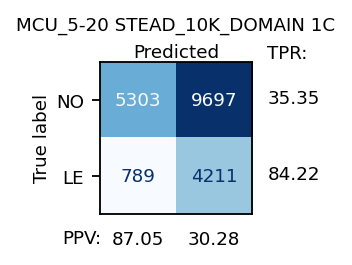

In [2]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt

# Fungsi untuk membuat diagram batang metrik komprehensif
def plot_comprehensive_metrics(metrics, save_path):
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    values = [metrics.get(k, 0) for k in keys]
    print(f"[DEBUG] Nilai yang akan diplot: {values}") 

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Average) - STEAD 10k 1C Benchmark')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Menambahkan label nilai di atas setiap batang
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
        
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik komprehensif tersimpan di: {save_path}")

# Main execution
if __name__ == "__main__":

    # ===================================================================
    # 1. KONFIGURASI PATH DAN PARAMETER (1C - KOMPONEN Z)
    # ===================================================================
    KEY_DATA_DIR = "/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_10000"
    KEY_TEST_FILE = 'STEAD_10k_1C_20260726_173059.json' # Sesuaikan dengan nama file JSON 1C Anda
    
    DATA_TAG = "STEAD_10K_DOMAIN"
    MODEL_TAG = "MCU_5-20"
    
    INPUT_WIN = 7  # Jendela waktu dalam detik
    SAMPLING_RATE = 100 # 100 Hz
    num_points = int(INPUT_WIN * SAMPLING_RATE) # 700 titik sampel
    
    # Label kelas: 'no' (Noise) = 0, 'le' (Local Earthquake) = 1
    true_labels = ["NO", "LE"]  
    source_to_code = {"no": 0, "le": 1}  

    # Direktori Model dan Embedding Referensi (UUSS) untuk 1C (Komponen Z)
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    # Menggunakan folder embedding tipikal UUSS
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

    # ===================================================================
    # 2. PERSIAPAN FILE DAN LOGGER
    # ===================================================================
    print(f"[INFO] Memuat Dataset Benchmark STEAD 10k (1C): {KEY_TEST_FILE}")
    json_path = os.path.join(KEY_DATA_DIR, KEY_TEST_FILE)
    
    test_data = dataset.load_json_data(json_path)
    keys_list = list(test_data.keys())
    print(f"[INFO] Total trace yang dimuat: {len(keys_list)}")

    # Setup folder output khusus 1C
    SAVE_BASE = '/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k_1c'
    time_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    os.makedirs(save_dir, exist_ok=True)

    # Konfigurasi sistem logging
    log_file_path = os.path.join(save_dir, "task_log_stead_10k_1c.txt")
    logging.basicConfig(level=logging.INFO,
                        format='%(asctime)s - [%(levelname)s]: %(message)s',
                        handlers=[
                            logging.FileHandler(log_file_path, mode='w'),
                            logging.StreamHandler()
                        ])
    logger = logging.getLogger()

    # ===================================================================
    # 3. MEMUAT MODEL DAN ESTIMASI KDE 1D (KOMPONEN Z)
    # ===================================================================
    logger.info("Memuat model deep learning MCU-Quake 1D...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    
    logger.info("Memuat data embedding referensi UUSS khusus Komponen Z...")
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")

    logger.info("Membangun model probabilitas spasial KDE 1D berdasarkan Komponen Z...")
    # Menggunakan fungsi PDF 1D untuk komponen Z dari library utils MCU-Quake
    embeddings_1C_PDFs = utils.embedding_PDFs_1D(embedding_Z)


    # ===================================================================
    # 4. PROSES INFERENSI (EVALUASI 1-KOMPONEN Z)
    # ===================================================================
    total_true = []
    total_pred = []
    
    logger.info("="*50)
    logger.info(f"Memulai iterasi inferensi 1C pada {len(keys_list)} data STEAD...")
    logger.info("="*50)

    for i in tqdm(range(len(keys_list)), desc="Inferensi STEAD 10k (1C)"):
        record_key = keys_list[i]
        record = test_data[record_key]
        
        # 'le' untuk gempa lokal, 'no' untuk noise
        true_label = record.get("type", "unknown") 
        
        try:
            # Slicing input window (700 sampel) hanya untuk komponen Z
            Z_n = np.array(record["Z_noise"][:num_points])
            Z_s = np.array(record["Z"][:num_points])

            # Ekstraksi Latent Codes untuk Noise Window (Z_noise) dan Signal Window (Z)
            _in_Zn = utils.latent_codes_1D(Z_n, embedding_model)
            _in_Zs = utils.latent_codes_1D(Z_s, embedding_model)

            # Inferensi KDE 1C untuk Noise Window
            emb_n = np.array([_in_Zn]).reshape(1, -1)
            p_n, _, _ = utils.infer_1C_PDFs(emb_n, embeddings_1C_PDFs, "Kernel")
            
            # Inferensi KDE 1C untuk Signal Window
            emb_s = np.array([_in_Zs]).reshape(1, -1)
            p_s, _, _ = utils.infer_1C_PDFs(emb_s, embeddings_1C_PDFs, "Kernel")
            
            # Logika Pelabelan Ground Truth Dinamis
            # Jendela prepick (noise) selalu bernilai 0 (Noise)
            true_n_class = 0 
            # Jendela utama bernilai 1 jika gempa ('le'), dan 0 jika ia memang noise murni ('no')
            true_s_class = 1 if true_label == "le" else 0
            
            # Tambahkan Ground Truth ke list
            total_true.extend([true_n_class, true_s_class]) 
            
            # Tambahkan Prediksi Model (Asumsi p >= 1.0 berarti Gempa)
            total_pred.extend([1 if p_n >= 1.0 else 0, 1 if p_s >= 1.0 else 0])
            
        except Exception as e:
            logger.error(f"Pengecualian (Error) pada trace {record_key}: {e}")
            continue

    # ===================================================================
    # 5. KALKULASI METRIK & PENYIMPANAN VISUALISASI
    # ===================================================================
    logger.info("="*50)
    logger.info("Mengkalkulasi Confusion Matrix dan Metrik Evaluasi (1C)...")
    
    # Hitung metrik komprehensif menggunakan utils
    matrix_1C, metrics_1C = utils.calc_confusion_metrics(total_true, total_pred)
    
    # Simpan Gambar Confusion Matrix
    conf_matrix_path = os.path.join(save_dir, "STEAD_10K_1C_confusion.jpg")
    fig_1C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 1C", true_labels, matrix_1C, metrics_1C)
    fig_1C.savefig(conf_matrix_path, dpi=300)
    logger.info(f"Confusion Matrix disimpan di: {conf_matrix_path}")
    
    # Simpan JSON Metrics
    metrics_json_path = os.path.join(save_dir, "stead_10k_1c_metrics.json")
    dataset.save_json_data(metrics_json_path, metrics_1C)
    logger.info(f"Detail metrik JSON disimpan di: {metrics_json_path}")
    
    # Buat Bar Chart Komprehensif
    bar_chart_path = os.path.join(save_dir, "STEAD_10K_1C_metrics_bar.jpg")
    plot_comprehensive_metrics(metrics_1C, bar_chart_path)

    # Ringkasan di Terminal
    logger.info("\n" + "*"*40)
    logger.info(f"  RINGKASAN PERFORMA - STEAD 10K 1C (Z-COMPONENT)")
    logger.info("*"*40)
    logger.info(f"  Akurasi (Accuracy) : {metrics_1C.get('Accuracy (avg.)', 0):.4f}")
    logger.info(f"  Presisi (Precision): {metrics_1C.get('Positive predictive value (avg.)', 0):.4f}")
    logger.info(f"  Sensitivitas (TPR) : {metrics_1C.get('True positive rate (avg.)', 0):.4f}")
    logger.info(f"  Skor F1 (F1-Score) : {metrics_1C.get('F1-score (avg.)', 0):.4f}")
    logger.info(f"  Alarm Palsu (FPR)  : {metrics_1C.get('False positive rate (avg.)', 0):.4f}")
    logger.info("*"*40)
    logger.info("Pengujian Benchmark 1C Selesai dengan Sukses.")